# KMeans com Split Temporal — alinhado ao XGBoost

Este notebook foi atualizado para utilizar **a mesma base, o mesmo corte temporal, a mesma engenharia de features e a mesma seleção de variáveis do notebook XGBoost**.

Fluxo:
- carregar o mesmo CSV do XGBoost;
- criar `prazo_transportadora_dias`, `purchase_month` e as mesmas features de interação;
- ordenar pela mesma coluna temporal;
- aplicar o mesmo corte em `2018-07-01`;
- remover as mesmas colunas consideradas vazamento/redundantes;
- aplicar o mesmo Target Encoding em `customer_city`, `seller_city` e `category_name`;
- manter as mesmas features finais do XGBoost;
- imputar valores ausentes pela mediana, pois o KMeans não aceita `NaN`;
- aplicar `StandardScaler`;
- treinar e avaliar o KMeans.

> Observação metodológica: o Target Encoding usa o alvo do conjunto de treino. Portanto, embora o algoritmo KMeans continue sendo de clusterização, essa etapa de preparação é supervisionada. Ela foi mantida aqui para garantir a comparação com exatamente as mesmas features usadas no XGBoost.


In [1]:
# Célula 1: bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
)
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


In [2]:
# Célula 2: leitura e preparação dos dados
# Mantida a mesma origem usada no notebook XGBoost.
csv_path = Path("../../tabela_final/table_orders_holidays_ecommerce_events.csv")
df = pd.read_csv(csv_path)

target_col = "delivered_on_time"
if target_col not in df.columns:
    raise ValueError(f"A coluna alvo '{target_col}' não foi encontrada no CSV.")

# =====================================================================
# 1. MESMA ENGENHARIA DE FEATURES DO XGBOOST
# =====================================================================
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"], utc=True, errors="coerce"
)
df["order_estimated_delivery_date"] = pd.to_datetime(
    df["order_estimated_delivery_date"], utc=True, errors="coerce"
)
df["order_delivered_carrier_date"] = pd.to_datetime(
    df["order_delivered_carrier_date"], utc=True, errors="coerce"
)

# Quantos dias existem entre a coleta pela transportadora
# e a data estimada de entrega.
df["prazo_transportadora_dias"] = (
    df["order_estimated_delivery_date"] - df["order_delivered_carrier_date"]
).dt.days

# Mesma regra do XGBoost.
df = df.dropna(subset=["prazo_transportadora_dias"]).copy()

# Sazonalidade.
df["purchase_month"] = df["order_purchase_timestamp"].dt.month

# Mesmas features de interação.
df["prazo_por_km"] = df["prazo_transportadora_dias"] / (df["distance_km"] + 1)
df["frete_por_kg"] = df["freight_value"] / (
    df["product_weight_g"] / 1000 + 0.1
)
df["densidade_produto"] = df["product_weight_g"] / (
    df["volume_cm3"] + 1
)

# =====================================================================
# 2. MESMA ORDENAÇÃO E MESMO SPLIT TEMPORAL DO XGBOOST
# =====================================================================
df = df.sort_values("order_delivered_carrier_date").reset_index(drop=True)

date_col = df["order_delivered_carrier_date"].copy()
split_date = pd.to_datetime("2018-07-01", utc=True)

# Mesmas colunas tratadas como vazamento no XGBoost.
leakage_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score",
]
leakage_cols = [c for c in leakage_candidates if c in df.columns]

feature_cols = [
    c for c in df.columns
    if c != target_col and c not in leakage_cols
]

X = df[feature_cols].copy()

# Mesma definição do alvo:
# 1 = atraso | 0 = não atraso.
y = (~df[target_col].astype(bool)).astype(int).copy()

# Mesma lista de remoção do notebook XGBoost.
colunas_remover = [
    "order_purchase_timestamp",
    "order_approved_at",
    "interval_code_delivered_carrier",
    "interval_code_delivered_customer",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "delivered_on_time",
    "review_score",

    # Features redundantes / de baixa influência removidas no XGBoost.
    "is_holiday_in_7_days",
    "is_holiday_in_14_days",
    "had_holiday_7_days_ago",
    "had_holiday_14_days_ago",
    "holiday_at_purchase",
    "is_weekend",
]

X = X.drop(columns=colunas_remover, errors="ignore")

train_mask = date_col < split_date
test_mask = date_col >= split_date

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

# =====================================================================
# 3. MESMO TARGET ENCODING SUAVIZADO DO XGBOOST
# =====================================================================
media_global_atraso = y_train.mean()
m = 10

# customer_city
counts_customer = X_train["customer_city"].value_counts()
means_customer = y_train.groupby(X_train["customer_city"]).mean()
smooth_customer = (
    counts_customer * means_customer + m * media_global_atraso
) / (counts_customer + m)

# seller_city
counts_seller = X_train["seller_city"].value_counts()
means_seller = y_train.groupby(X_train["seller_city"]).mean()
smooth_seller = (
    counts_seller * means_seller + m * media_global_atraso
) / (counts_seller + m)

X_train["customer_city_encoded"] = X_train["customer_city"].map(smooth_customer)
X_train["seller_city_encoded"] = X_train["seller_city"].map(smooth_seller)

X_test["customer_city_encoded"] = (
    X_test["customer_city"].map(smooth_customer).fillna(media_global_atraso)
)
X_test["seller_city_encoded"] = (
    X_test["seller_city"].map(smooth_seller).fillna(media_global_atraso)
)

# category_name
X_train["category_name"] = X_train["category_name"].fillna("Unknown")
X_test["category_name"] = X_test["category_name"].fillna("Unknown")

counts_cat = X_train["category_name"].value_counts()
means_cat = y_train.groupby(X_train["category_name"]).mean()
smooth_cat = (
    counts_cat * means_cat + m * media_global_atraso
) / (counts_cat + m)

X_train["category_name_encoded"] = (
    X_train["category_name"].map(smooth_cat).fillna(media_global_atraso)
)
X_test["category_name_encoded"] = (
    X_test["category_name"].map(smooth_cat).fillna(media_global_atraso)
)

# Remove as strings originais, exatamente como no XGBoost.
X_train = X_train.drop(
    columns=["customer_city", "seller_city", "category_name"]
)
X_test = X_test.drop(
    columns=["customer_city", "seller_city", "category_name"]
)

# Garante que booleanos sejam numéricos.
bool_cols = X_train.select_dtypes(include=["bool"]).columns
for col in bool_cols:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)

# Segurança: KMeans trabalha apenas com valores numéricos.
non_numeric_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()
if non_numeric_cols:
    raise TypeError(
        "Ainda existem colunas não numéricas antes do KMeans: "
        + ", ".join(non_numeric_cols)
    )

# Substitui infinitos por NaN para que possam ser imputados.
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

total_linhas = len(X)
qtd_treino = len(X_train)
qtd_teste = len(X_test)

print(f"Total de registros: {total_linhas:,}")
print(f"Treino (até Jun/2018): {qtd_treino:,} ({qtd_treino/total_linhas:.2%})")
print(
    f" - Atrasos no Treino: {(y_train == 1).sum():,} "
    f"({(y_train == 1).mean():.2%} do treino)"
)
print(f"Teste (Jul/2018 em diante): {qtd_teste:,} ({qtd_teste/total_linhas:.2%})")
print(
    f" - Atrasos no Teste: {(y_test == 1).sum():,} "
    f"({(y_test == 1).mean():.2%} do teste)"
)

print(f"\nNúmero de features finais: {X_train.shape[1]}")
print("\nFeatures usadas:")
display(pd.DataFrame({"feature": X_train.columns}))


Total de registros: 33,820
Treino (até Jun/2018): 28,706 (84.88%)
 - Atrasos no Treino: 1,425 (4.96% do treino)
Teste (Jul/2018 em diante): 5,114 (15.12%)
 - Atrasos no Teste: 613 (11.99% do teste)

Número de features finais: 26

Features usadas:


,feature
0,holiday_at_carrier
1,days_since_last_holiday
2,days_until_next_holiday
3,ecommerce_event_at_carrier
4,days_since_last_ecommerce_event
5,days_until_next_ecommerce_event
6,is_ecommerce_event_in_7_days
7,is_ecommerce_event_in_14_days
8,had_ecommerce_event_7_days_ago
9,had_ecommerce_event_14_days_ago


In [3]:
# Célula 3: imputação + padronização
# O XGBoost tolera NaN; o KMeans não.
# Por isso, esta é a única adaptação necessária ao algoritmo.

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=X_train_imputed.columns,
    index=X_train_imputed.index,
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=X_test_imputed.columns,
    index=X_test_imputed.index,
)

print(f"Shape treino padronizado: {X_train_scaled.shape}")
print(f"Shape teste padronizado: {X_test_scaled.shape}")
display(X_train_scaled.head())


Shape treino padronizado: (28706, 26)
Shape teste padronizado: (5114, 26)


,holiday_at_carrier,days_since_last_holiday,days_until_next_holiday,ecommerce_event_at_carrier,days_since_last_ecommerce_event,days_until_next_ecommerce_event,is_ecommerce_event_in_7_days,is_ecommerce_event_in_14_days,had_ecommerce_event_7_days_ago,had_ecommerce_event_14_days_ago,purchase_hour,purchase_day_of_week,price,freight_value,product_weight_g,volume_cm3,distance_km,same_city,prazo_transportadora_dias,purchase_month,prazo_por_km,frete_por_kg,densidade_produto,customer_city_encoded,seller_city_encoded,category_name_encoded
0,-0.0318,0.965208,-1.218797,-0.107675,0.121124,-1.327019,3.027377,2.14733,-0.352708,-0.512262,1.368521,-1.010425,-0.510359,-0.253312,2.666846,-0.607551,0.325164,-0.399036,4.599485,1.246555,-0.167195,-1.207121,5.783797,-0.536481,-0.010843,-2.321315
1,-0.0318,1.120338,-1.378173,-0.107675,0.172032,-1.384377,3.027377,2.14733,-0.352708,-0.512262,-0.700346,0.051786,0.461333,-0.087124,-0.274718,-0.300848,0.373216,-0.399036,4.599485,1.246555,-0.178453,-0.464373,-0.117285,1.152325,0.043177,-1.305865
2,-0.0318,1.120338,-1.378173,-0.107675,0.172032,-1.384377,3.027377,2.14733,-0.352708,-0.512262,-0.700346,0.582891,-0.422016,-0.236693,-0.435596,-0.549873,1.023441,-0.399036,5.057406,1.246555,-0.265006,0.114058,-0.094446,-0.001782,1.815602,1.088629
3,-0.0318,1.120338,-1.378173,-0.107675,0.172032,-1.384377,3.027377,2.14733,-0.352708,-0.512262,0.051970,-0.479319,-0.025242,3.782692,2.158427,3.395606,-0.953592,-0.399036,4.446844,1.246555,3.320280,-1.034727,-0.131261,-0.300868,0.043177,-0.437373
4,-0.0318,1.120338,-1.378173,-0.107675,0.172032,-1.384377,3.027377,2.14733,-0.352708,-0.512262,1.368521,0.051786,-0.567770,0.815042,0.233701,0.528851,1.336574,-0.399036,4.599485,1.246555,-0.309495,-0.835074,-0.135673,0.659970,-1.694304,0.836058


--- MÉTODO DO COTOVELO ---
Cotovelo detectado automaticamente: k=4
k=2 também será avaliado por representar atraso vs. não atraso.


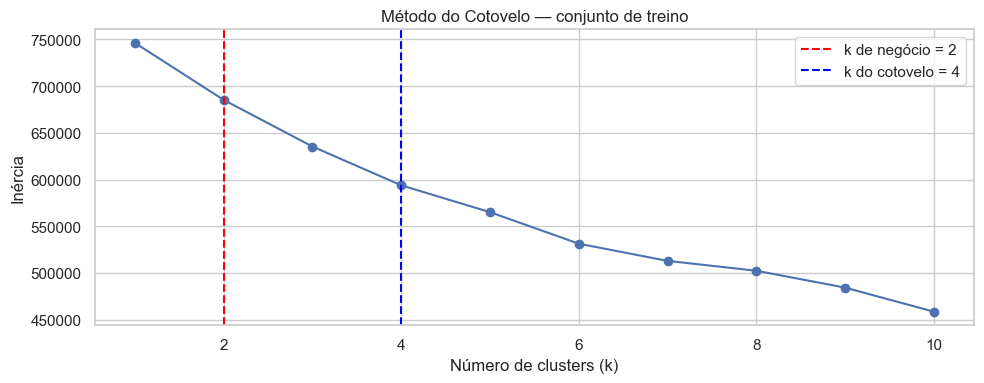

In [4]:
# Célula 4: método do cotovelo
inertias = []
k_range = range(1, 11)

for k in k_range:
    model = KMeans(
        n_clusters=k,
        random_state=4242,
        n_init=10,
    )
    model.fit(X_train_scaled)
    inertias.append(model.inertia_)

# Detecção automática aproximada do "cotovelo"
p1 = np.array([k_range[0], inertias[0]])
p2 = np.array([k_range[-1], inertias[-1]])
line_vec = p2 - p1
line_norm = np.linalg.norm(line_vec)

distances = []
for idx, k in enumerate(k_range):
    p0 = np.array([k, inertias[idx]])
    point_vec = p1 - p0
    distance = abs(
        line_vec[0] * point_vec[1] -
        line_vec[1] * point_vec[0]
    ) / line_norm
    distances.append(distance)

elbow_k = list(k_range)[int(np.argmax(distances))]
optimal_k = 2

print("--- MÉTODO DO COTOVELO ---")
print(f"Cotovelo detectado automaticamente: k={elbow_k}")
print("k=2 também será avaliado por representar atraso vs. não atraso.")

plt.figure(figsize=(10, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.axvline(
    optimal_k,
    color="red",
    linestyle="--",
    label=f"k de negócio = {optimal_k}",
)
plt.axvline(
    elbow_k,
    color="blue",
    linestyle="--",
    label=f"k do cotovelo = {elbow_k}",
)
plt.title("Método do Cotovelo — conjunto de treino")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# Célula 5: função de avaliação
def avaliar_kmeans(k, X_train, X_test, y_train, y_test):
    print("=" * 70)
    print(f"AVALIAÇÃO DO KMEANS COM K = {k}".center(70))
    print("=" * 70)

    # ---------------------------------------------------------------
    # 1. Treinamento
    # ---------------------------------------------------------------
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=4242,
        n_init=10,
    )

    train_clusters = kmeans_model.fit_predict(X_train)
    test_clusters = kmeans_model.predict(X_test)

    # ---------------------------------------------------------------
    # 2. Mapeamento cluster -> classe
    # Usa apenas o y de treino para interpretar os clusters.
    # ---------------------------------------------------------------
    cluster_rows = []
    global_delay_rate = float(y_train.mean())

    y_train_array = np.asarray(y_train)

    for cluster_id in range(k):
        cluster_mask = train_clusters == cluster_id
        cluster_size = int(cluster_mask.sum())

        if cluster_size == 0:
            continue

        delay_rate = float(y_train_array[cluster_mask].mean())

        cluster_rows.append({
            "cluster": cluster_id,
            "tamanho": cluster_size,
            "taxa_atraso": delay_rate,
            "classe_mapeada": 1 if delay_rate >= global_delay_rate else 0,
        })

    cluster_summary = (
        pd.DataFrame(cluster_rows)
        .sort_values("taxa_atraso", ascending=False)
        .reset_index(drop=True)
    )

    cluster_to_class = dict(
        zip(
            cluster_summary["cluster"],
            cluster_summary["classe_mapeada"],
        )
    )

    mapped_train_clusters = np.array([
        cluster_to_class.get(c, 0)
        for c in train_clusters
    ])

    mapped_test_clusters = np.array([
        cluster_to_class.get(c, 0)
        for c in test_clusters
    ])

    print(f"\nTaxa global de atraso no treino: {global_delay_rate:.2%}")
    print("\nResumo por cluster:")
    display(cluster_summary.round(4))

    # ---------------------------------------------------------------
    # 3. Métricas compatíveis com classificação
    # ---------------------------------------------------------------
    def calcular_metricas(y_true, y_pred):
        return {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
            "Precision atraso": precision_score(
                y_true, y_pred, zero_division=0
            ),
            "Recall atraso": recall_score(
                y_true, y_pred, zero_division=0
            ),
            "F1 atraso": f1_score(
                y_true, y_pred, zero_division=0
            ),
            "F2 atraso": fbeta_score(
                y_true, y_pred, beta=2, zero_division=0
            ),
        }

    metricas_treino = calcular_metricas(
        y_train,
        mapped_train_clusters,
    )
    metricas_teste = calcular_metricas(
        y_test,
        mapped_test_clusters,
    )

    comparacao = pd.DataFrame({
        "Treino": metricas_treino,
        "Teste": metricas_teste,
    })

    print("\nMétricas:")
    display(comparacao.round(4))

    # ---------------------------------------------------------------
    # 4. Matriz de confusão + PCA
    # ---------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(y_test, mapped_test_clusters)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Não atraso", "Atraso"],
        yticklabels=["Não atraso", "Atraso"],
        ax=axes[0],
    )
    axes[0].set_title(f"Matriz de Confusão — Teste (k={k})")
    axes[0].set_xlabel("Predito")
    axes[0].set_ylabel("Real")

    pca = PCA(n_components=2, random_state=4242)
    X_train_pca = pca.fit_transform(X_train.to_numpy())
    centroids_pca = pca.transform(kmeans_model.cluster_centers_)

    scatter = axes[1].scatter(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        c=train_clusters,
        cmap="viridis",
        alpha=0.7,
        s=25,
    )

    axes[1].scatter(
        centroids_pca[:, 0],
        centroids_pca[:, 1],
        marker="*",
        s=320,
        c="red",
        edgecolor="black",
        label="Centroides",
    )

    legend_clusters = axes[1].legend(
        *scatter.legend_elements(),
        title="Cluster",
        loc="best",
    )
    axes[1].add_artist(legend_clusters)
    axes[1].legend(loc="upper right")
    axes[1].set_title(f"PCA — Treino (k={k})")
    axes[1].set_xlabel("Componente 1")
    axes[1].set_ylabel("Componente 2")

    plt.tight_layout()
    plt.show()

    return {
        "modelo": kmeans_model,
        "resumo_clusters": cluster_summary,
        "cluster_to_class": cluster_to_class,
        "metricas_treino": metricas_treino,
        "metricas_teste": metricas_teste,
        "predicoes_teste": mapped_test_clusters,
    }   

print("Função de avaliação declarada.")


Função de avaliação declarada.


                    AVALIAÇÃO DO KMEANS COM K = 2                     

Taxa global de atraso no treino: 4.96%

Resumo por cluster:


,cluster,tamanho,taxa_atraso,classe_mapeada
0,1,23590,0.0515,1
1,0,5116,0.0409,0



Métricas:


,Treino,Teste
Accuracy,0.2133,0.2961
Balanced Accuracy,0.5166,0.4049
Precision atraso,0.0515,0.0918
Recall atraso,0.8533,0.5481
F1 atraso,0.0972,0.1573
F2 atraso,0.2076,0.2749


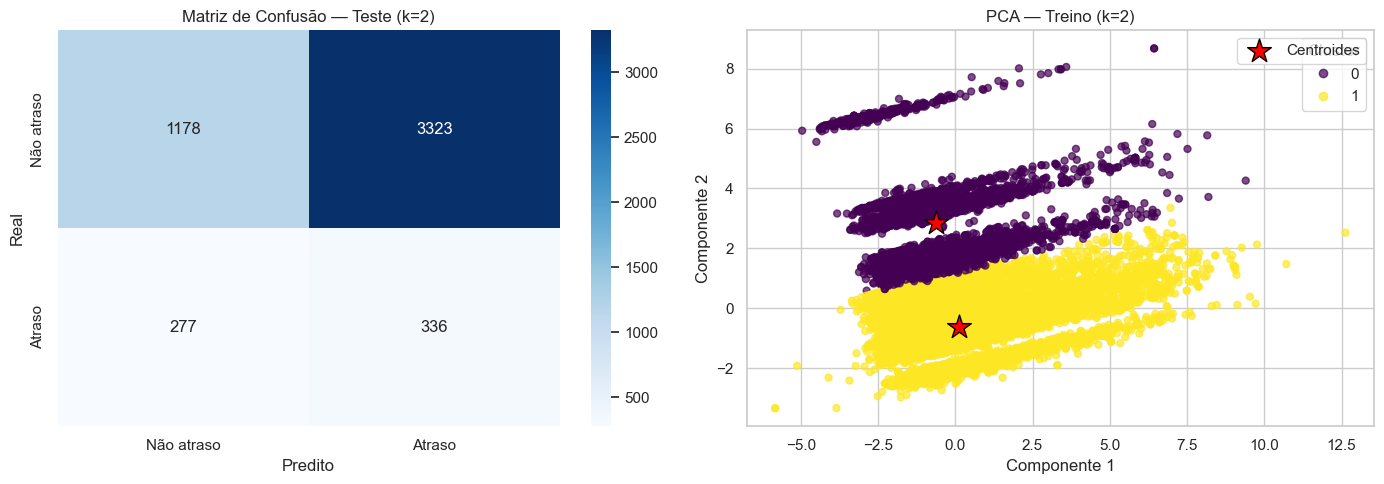

In [6]:
# Célula 6: avaliação com k=2
resultado_k2 = avaliar_kmeans(
    k=2,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
)


                    AVALIAÇÃO DO KMEANS COM K = 4                     

Taxa global de atraso no treino: 4.96%

Resumo por cluster:


,cluster,tamanho,taxa_atraso,classe_mapeada
0,0,5165,0.0594,1
1,2,2774,0.0588,1
2,1,15952,0.0483,0
3,3,4815,0.0384,0



Métricas:


,Treino,Teste
Accuracy,0.7065,0.6384
Balanced Accuracy,0.5280,0.5438
Precision atraso,0.0592,0.1469
Recall atraso,0.3298,0.4192
F1 atraso,0.1004,0.2175
F2 atraso,0.1723,0.3058


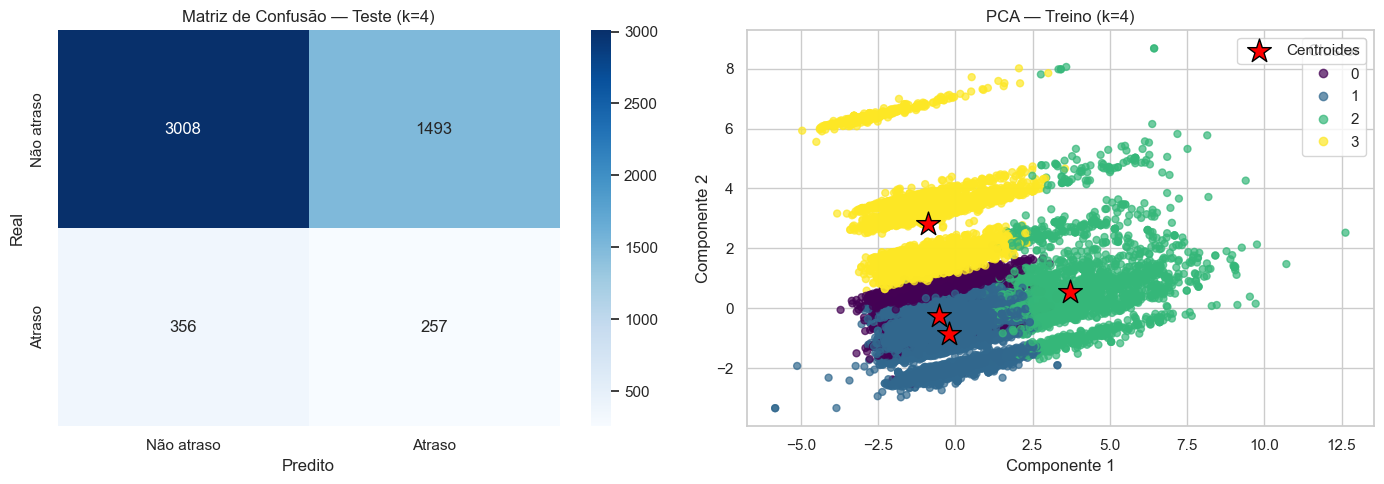

In [7]:
# Célula 7: avaliação com k identificado pelo método do cotovelo
# Evita repetir exatamente a mesma avaliação caso elbow_k também seja 2.
if elbow_k != 2:
    resultado_elbow = avaliar_kmeans(
        k=elbow_k,
        X_train=X_train_scaled,
        X_test=X_test_scaled,
        y_train=y_train,
        y_test=y_test,
    )
else:
    print("O método do cotovelo também selecionou k=2; não é necessário repetir a avaliação.")


In [8]:
# Célula: salvar modelo KMeans em .pkl

import pickle

kmeans_package = {
    # Modelo KMeans
    "model": resultado_k2["modelo"],

    # Pré-processamento
    "imputer": imputer,
    "scaler": scaler,

    # Ordem exata das features usadas durante o treinamento
    "feature_names": X_train.columns.tolist(),

    # Target Encoding
    "media_global_atraso": media_global_atraso,
    "smooth_customer": smooth_customer.to_dict(),
    "smooth_seller": smooth_seller.to_dict(),
    "smooth_category": smooth_cat.to_dict(),

    # Conversão do cluster em classe
    # 0 = não atraso
    # 1 = atraso
    "cluster_to_class": resultado_k2["cluster_to_class"],

    # Informações auxiliares
    "cluster_summary": resultado_k2["resumo_clusters"],
    "n_clusters": resultado_k2["modelo"].n_clusters,
}

with open("kmeans_model.pkl", "wb") as arquivo:
    pickle.dump(kmeans_package, arquivo)

print("✅ kmeans_model.pkl gerado com sucesso!")

✅ kmeans_model.pkl gerado com sucesso!


## Observações para comparação com o XGBoost

Agora os dois notebooks usam a mesma lógica de construção das variáveis de entrada e o mesmo período de treino/teste.

As métricas **Accuracy, Precision, Recall, F1 e F2** podem ser colocadas lado a lado com os modelos supervisionados após o mapeamento dos clusters para as classes de atraso/não atraso.

Entretanto, a interpretação deve deixar claro que o KMeans é originalmente um algoritmo de clusterização e não produz probabilidades de classe como o XGBoost. Por isso, métricas dependentes de probabilidade, como ROC-AUC, PR-AUC, Brier Score e Log Loss, não foram artificialmente calculadas para o KMeans.
